In [1]:
# Notebook to reproduce the plots for the simulation results.
# Please note that the size of sim-results.csv (~1.4 GB) does not allow an upload to github.
# You can find the file at https://uni-muenster.sciebo.de/s/T4bmt6gWdFpxRiN


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from cmcrameri import cm as cmc
import matplotlib.colors as mcolors
import matplotlib.cm as mpl_cm
import seaborn as sns
import numpy as np
import math
from matplotlib.gridspec import GridSpec


DF = pd.read_csv("../_exampledata/sim-results.csv")


In [3]:
# rename columns for better readability
DF = DF.rename(columns= {
    "H" : "1-P(Type II Error)",
    "FA" : "P(Type I Error)",
    "trl_noise" : "Trial Noise (log)",
    "n_subjects" : "N Subjects",
    "n_phase_bins" : "N Phase Bins",
    "n_perms" : "N Permutations",
    "n_trials" : "N Trials",
    "range_bin" : "Binning Width (*2pi)",
    "stat_type" : "Statistic",
    "intersubj_noise" : "Intersubjects Noise (log)",
    "mc_method" : "FWER Correction",
    "effect_mag" : "Effect Magnitude",
    })

# replace values for better readability
DF['FWER Correction'] = DF['FWER Correction'].replace('omni', 'Omnibus')
DF['FWER Correction'] = DF['FWER Correction'].replace('circ', 'CircClust')
DF['Statistic'] = DF['Statistic'].replace('Tval', 't-value')

In [4]:
# convenience global indexes and plotsettings
DFpr = DF.loc[DF["Effect Magnitude"]>0, :]
DFabs = DF.loc[DF["Effect Magnitude"]==0, :]

seed_fontsize = 18
fontsize_suptitle=round(seed_fontsize*1.2)
fontsize_title=round(seed_fontsize*1.1)
fontsize_axis_label=seed_fontsize
fontsize_tick=seed_fontsize*.9
fontsize_annot=seed_fontsize*.9
fontsize_cbar_label=seed_fontsize
fontsize_cbar_tick=seed_fontsize*.9

In [5]:
# convenioence function for heatmap panels
def plot_heatmap_panels(df, ind_var1, ind_var2, ind_var3, dep_var,
                        title=None,vmin=None, vmax=None, fmt='.2f',
                        figsize_per_panel=(5, 5), ncols=None, nrows=None,
                        annot=True, linecolor="white"):

    unique_vals = sorted(df[ind_var1].unique())
    n = len(unique_vals)

    # Pivot tables
    pivots = {
        v: df[df[ind_var1] == v].pivot_table(
            index=ind_var2, columns=ind_var3, values=dep_var, aggfunc='mean'
        ) for v in unique_vals
    }

    # Global limits
    vmin = vmin if vmin is not None else min(p.min().min() for p in pivots.values())
    vmax = vmax if vmax is not None else max(p.max().max() for p in pivots.values())

    # Balanced grid (n panels + 1 cell for colorbar)
    if not ncols:
        ncols = math.ceil(math.sqrt(n + 1))
    if not nrows:
        nrows = math.ceil((n + 1) / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_panel[0] * ncols,
                                      figsize_per_panel[1] * nrows))
    axes = axes.flatten()

    # Heatmaps
    for i, val in enumerate(unique_vals):
        sns.heatmap(pivots[val], ax=axes[i], vmin=vmin, vmax=vmax,
                    cmap=cmc.vik, annot=annot, fmt=fmt,
                    annot_kws={'size': fontsize_annot}, cbar=False,
                    linewidths=.5, linecolor=linecolor)
        row = i // ncols
        is_last_row = (row == nrows - 1) or (i + ncols >= n)

        axes[i].set_title(f'{ind_var1} = {val}', fontsize=fontsize_title)
        axes[i].set_xlabel(ind_var3 if is_last_row else '', fontsize=fontsize_axis_label)
        axes[i].set_ylabel(ind_var2 if i % nrows == 0 else '', fontsize=fontsize_axis_label)
        axes[i].tick_params(labelsize=fontsize_tick)

    # Colorbar in the next subplot cell
    cbar_ax = axes[-1]
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl_cm.ScalarMappable(cmap=cmc.vik, norm=norm)
    cbar = fig.colorbar(sm, ax=cbar_ax, orientation='horizontal', fraction=0.6)
    cbar.set_label(f'{dep_var}', fontsize=fontsize_axis_label)
    cbar.ax.tick_params(labelsize=fontsize_tick)
    cbar_ax.set_visible(False)  # hide the empty axes behind the colorbar

    # Hide remaining unused cells
    for j in range(i + 1, len(axes)-1):
        axes[j].set_visible(False)

    plt.tight_layout(h_pad=3)

    plt.subplots_adjust(top=0.90)
    plt.suptitle(title, fontsize=fontsize_suptitle)

    plt.show()



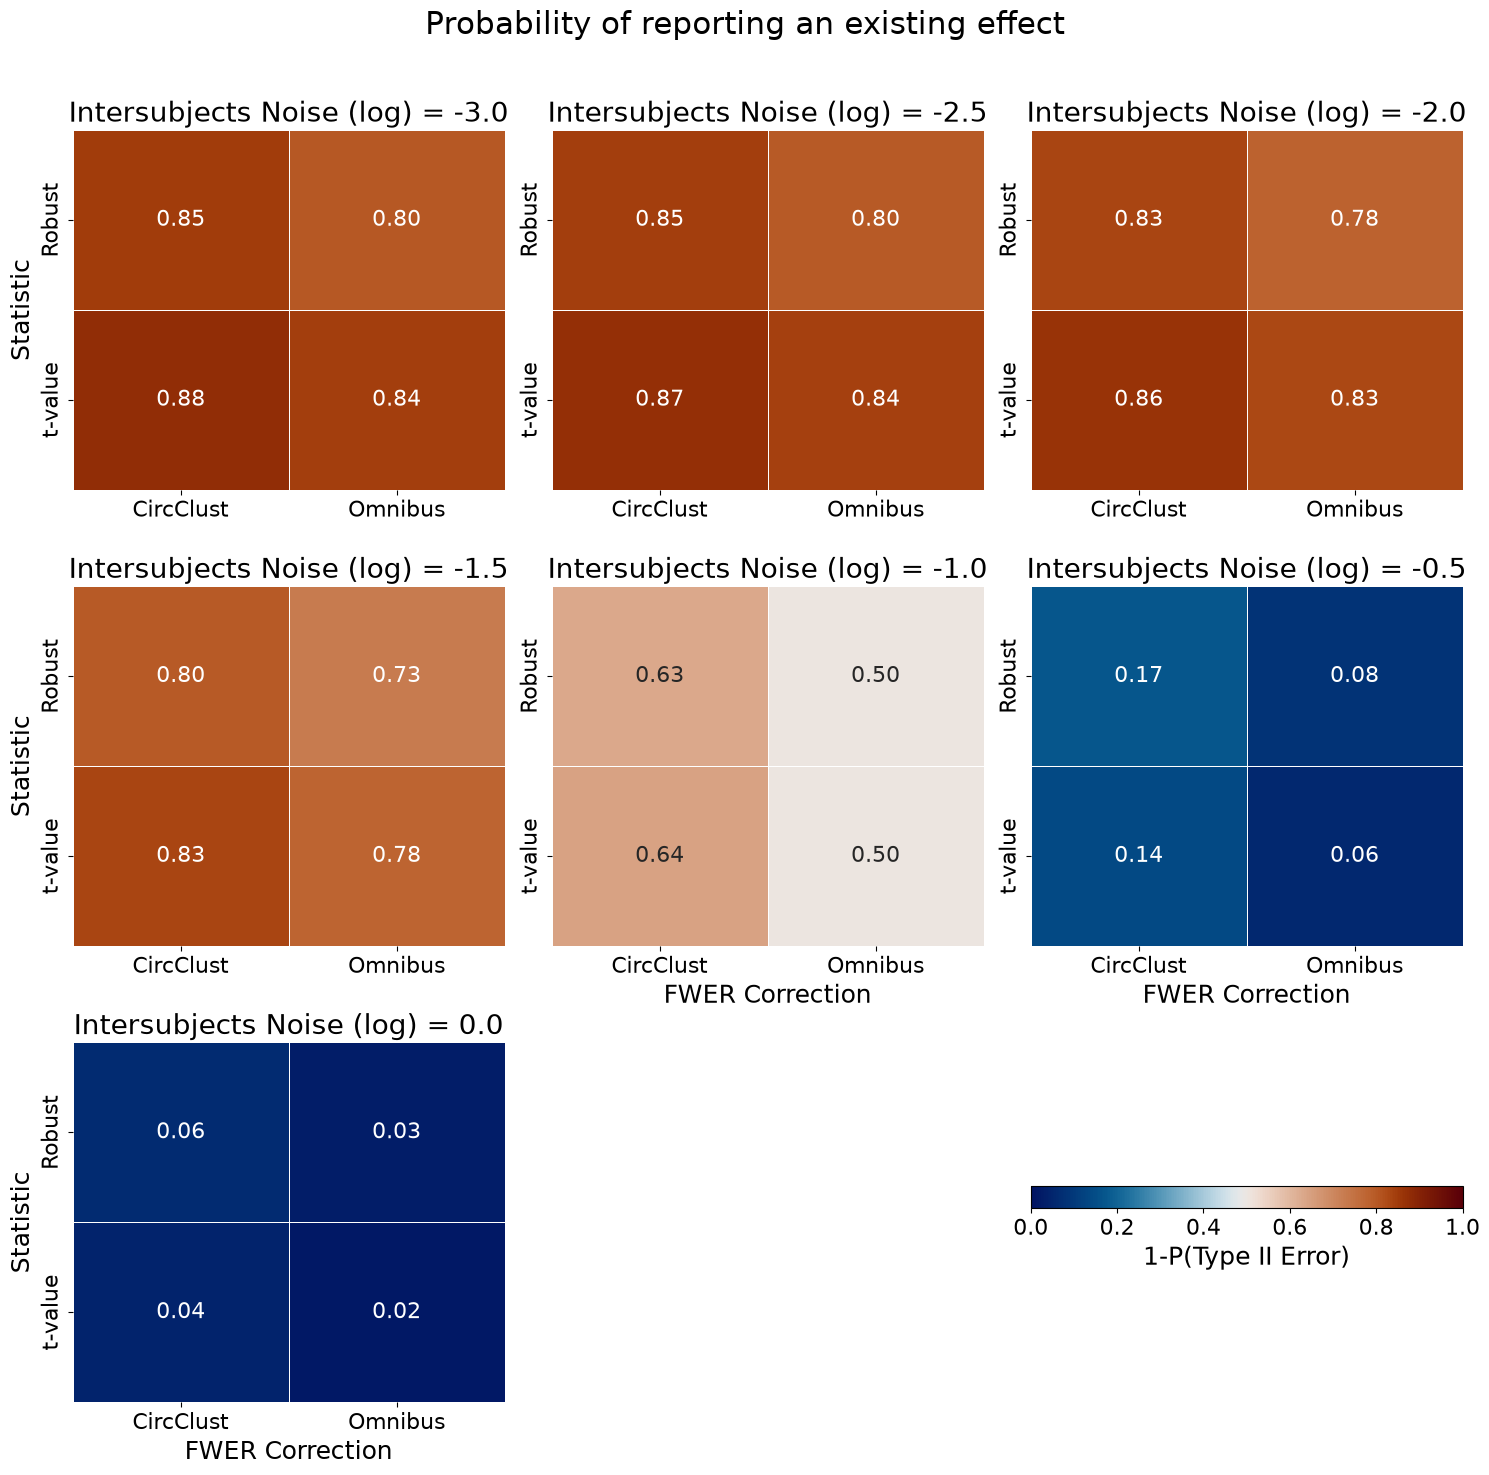

In [6]:
# provide plots for various level of intersubject noise
plot_heatmap_panels(DFpr, ind_var1="Intersubjects Noise (log)", 
                    ind_var2="Statistic", 
                    ind_var3="FWER Correction", 
                    dep_var="1-P(Type II Error)", 
                    title="Probability of reporting an existing effect",
                    vmin=0,
                    vmax=1, 
                   )


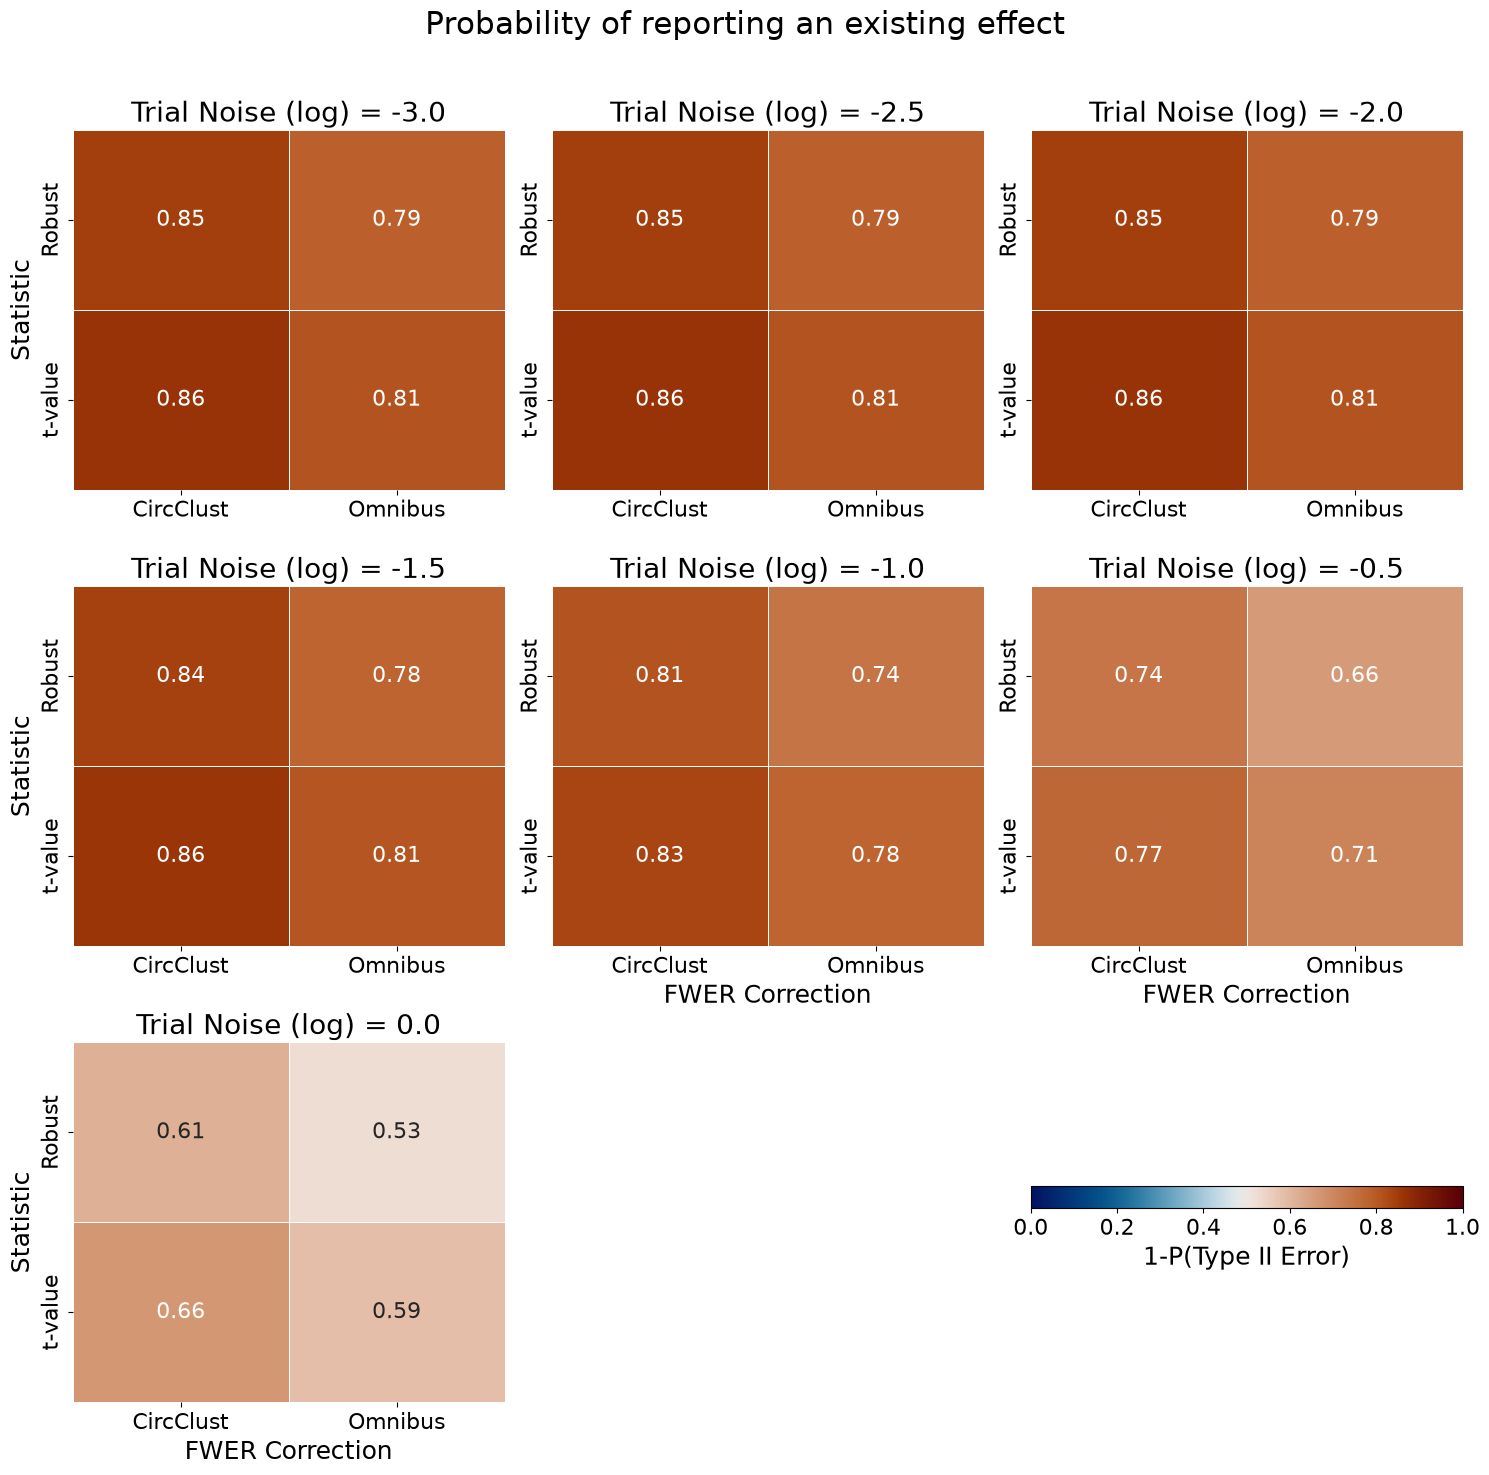

In [7]:
# subselect for those intersubject noise levels that still allow to report an effect
slicedDFpr = DFpr.loc[DFpr["Intersubjects Noise (log)"]<-.5, :]

# Plot for various single trial noise levels
plot_heatmap_panels(slicedDFpr, ind_var1="Trial Noise (log)", 
                    ind_var2="Statistic", 
                    ind_var3="FWER Correction", 
                    dep_var="1-P(Type II Error)",                     
                    title="Probability of reporting an existing effect",
                    vmin=0,
                    vmax=1)


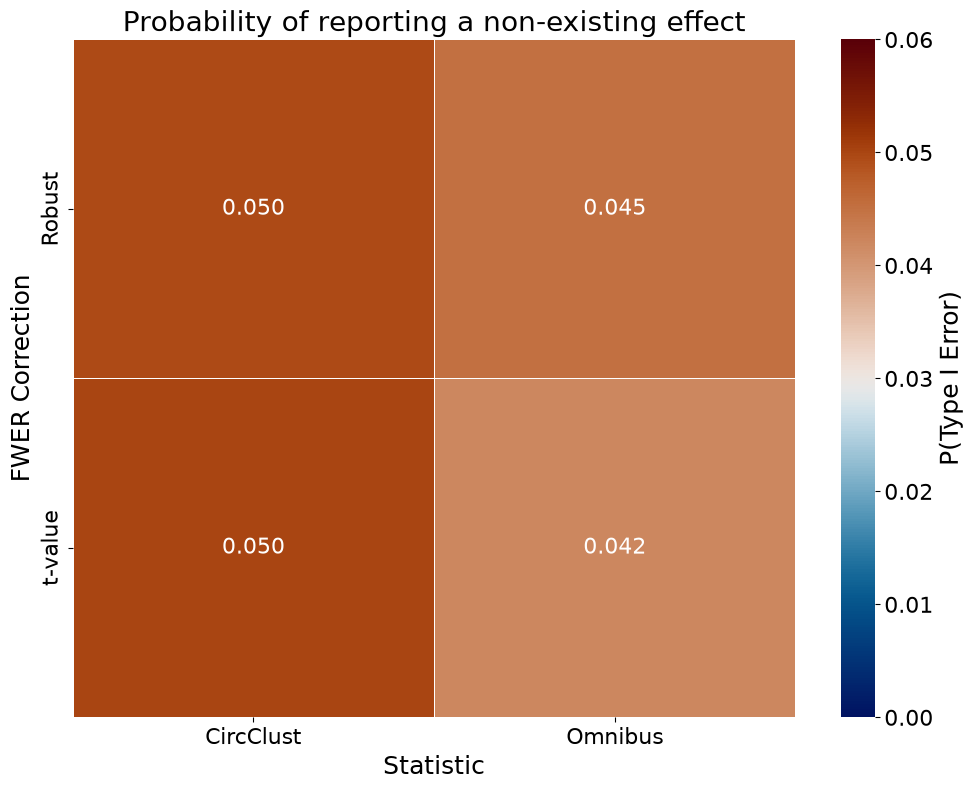

In [8]:
# select effect-absent simulations
pivot = DFabs.pivot_table(
    index="Statistic", columns="FWER Correction",
    values="P(Type I Error)", aggfunc='mean'
)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(pivot, annot=True,
            fmt=".3f",
            annot_kws={'size': fontsize_annot},   # ← annotation fontsize
            linewidths=0.5,
            linecolor='white',
            vmin=0,
            vmax=.06,
            cmap=cmc.vik,
            )

# Access the colorbar AFTER creation
cbar = ax.collections[0].colorbar

# Now set font sizes
cbar.set_label("P(Type I Error)", fontsize=fontsize_cbar_label)   # label fontsize
cbar.ax.tick_params(labelsize=fontsize_cbar_tick)         # tick fontsize

ax.set_xlabel("Statistic", fontsize=fontsize_axis_label)
ax.set_ylabel("FWER Correction", fontsize=fontsize_axis_label)
ax.tick_params(labelsize=fontsize_tick)

plt.title("Probability of reporting a non-existing effect", fontsize=fontsize_title)

plt.tight_layout()


Text(0.5, 0.98, 'Probability of reporting an existing effect')

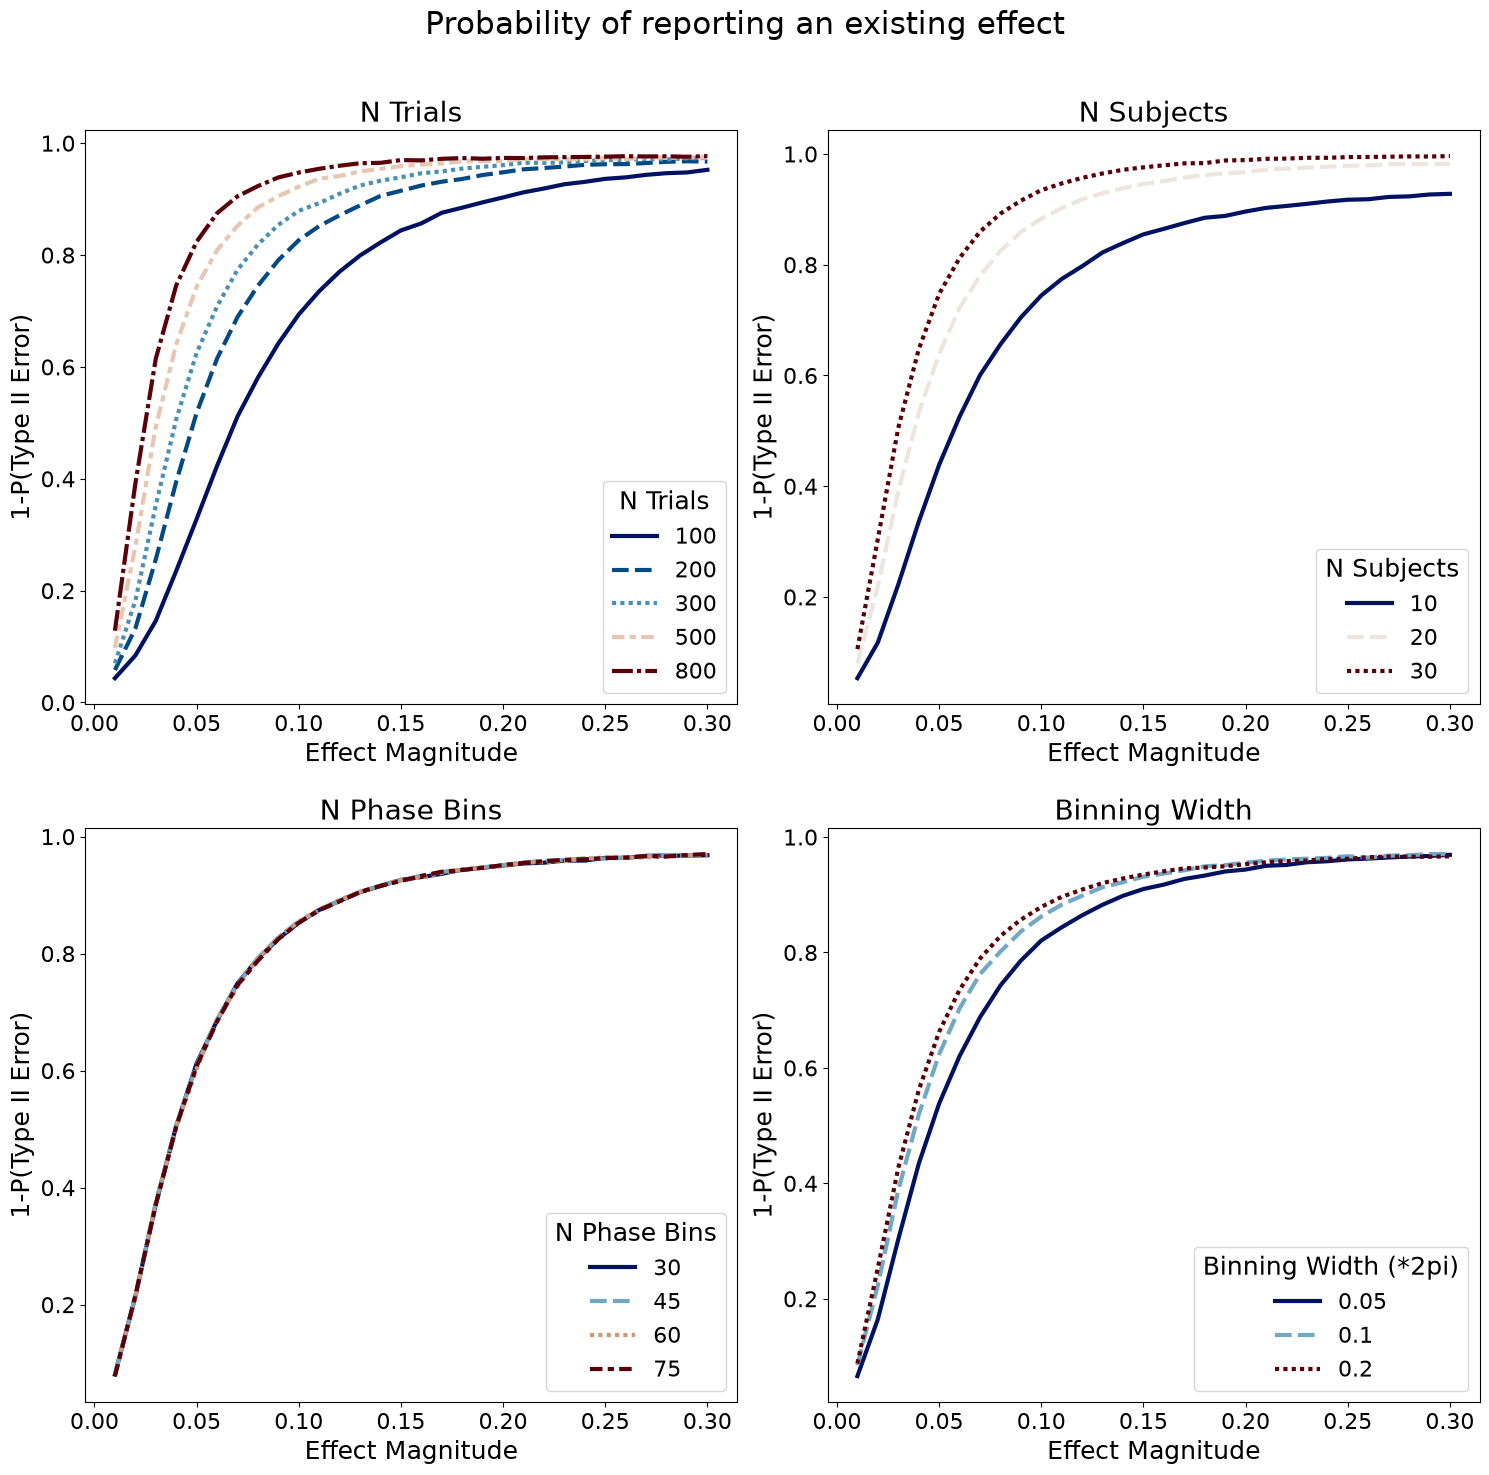

In [9]:
# evaluate probability of reporting an existing effect
# as by changing N trials, N subjets, N phase bins, and Binning Width
# as a function of noise magnitude

def wrap_lineplot(DATA, XAXvar, YAXvar, HUEvar, PAL=cmc.vik):

    ax = sns.lineplot(data=DATA, x=XAXvar, y=YAXvar, hue=HUEvar, style=HUEvar, 
                      errorbar=None, palette=PAL, legend="full", linewidth=3)
    ax.set_xlabel(XAXvar, fontsize=fontsize_axis_label)
    ax.set_ylabel(YAXvar, fontsize=fontsize_axis_label)
    ax.tick_params(axis='both', labelsize=fontsize_tick)
    ax.legend(fontsize=fontsize_tick, title=HUEvar, 
              title_fontsize=fontsize_axis_label, loc=4)
    plt.title(HUEvar, fontsize=fontsize_title)

#%%

mask_CircClustTvals = ((slicedDFpr["FWER Correction"]=="CircClust") & 
                       (slicedDFpr["Statistic"]=="t-value"))
lowNoiseCCtval = slicedDFpr.loc[mask_CircClustTvals, :]

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(221)
wrap_lineplot(lowNoiseCCtval, "Effect Magnitude", "1-P(Type II Error)", "N Trials")
fig.add_subplot(222)
wrap_lineplot(lowNoiseCCtval, "Effect Magnitude", "1-P(Type II Error)", "N Subjects")
fig.add_subplot(223)
wrap_lineplot(lowNoiseCCtval, "Effect Magnitude", "1-P(Type II Error)", "N Phase Bins")
fig.add_subplot(224)
wrap_lineplot(lowNoiseCCtval, "Effect Magnitude", "1-P(Type II Error)", "Binning Width (*2pi)")
plt.title("Binning Width", fontsize=fontsize_title)

plt.tight_layout(h_pad=3)

plt.subplots_adjust(top=0.90)
plt.suptitle("Probability of reporting an existing effect", fontsize=fontsize_suptitle)


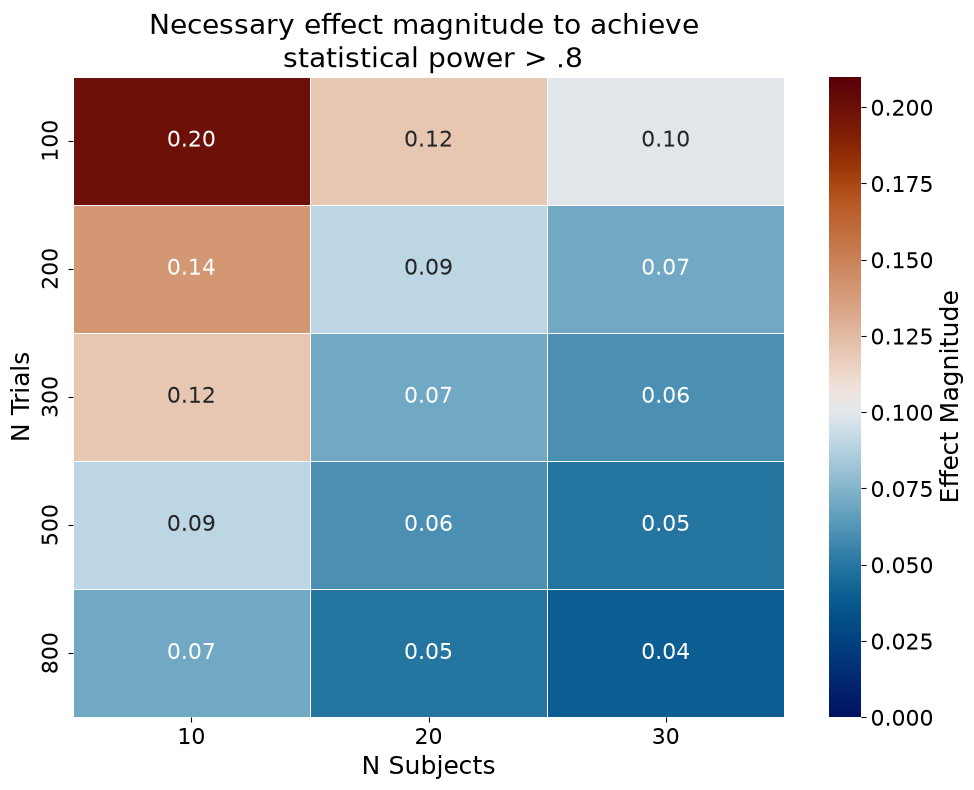

In [10]:
ind_var1="N Subjects" 
ind_var2="N Trials" 
ind_var3="Effect Magnitude"
dep_var="1-P(Type II Error)"
uniNsubj = sorted(lowNoiseCCtval[ind_var1].unique())
uniNTrial = sorted(lowNoiseCCtval[ind_var2].unique())
uniMag = sorted(lowNoiseCCtval[ind_var3].unique())

tmp_dict = {}
for Nsubj in uniNsubj:
    
    m1 = lowNoiseCCtval[ind_var1] == Nsubj
    tmp_dict.update({Nsubj : {}})
    
    for NTrials in uniNTrial:
        
        m2 = lowNoiseCCtval[ind_var2] == NTrials

        for iMag in uniMag:
        
            m3 = lowNoiseCCtval[ind_var3] == iMag
        
            subDF = lowNoiseCCtval.loc[m1 & m2 & m3, :]
        
            P = subDF[dep_var].mean()
    
            if P>=.8:
                tmp_dict[Nsubj].update({NTrials : iMag})
                break
            else:
                continue


lastDF = pd.DataFrame().from_dict(tmp_dict)



plt.figure(figsize=(10, 8))
ax = sns.heatmap(lastDF, annot=True,
            fmt=".2f",
            annot_kws={'size': fontsize_annot},   # ← annotation fontsize
            linewidths=0.5,
            linecolor='white',
            vmin=0,
            vmax=.21,
            cmap=cmc.vik,
            )

# Access the colorbar AFTER creation
cbar = ax.collections[0].colorbar

# Now set font sizes
cbar.set_label(ind_var3, fontsize=fontsize_cbar_label)   # label fontsize
cbar.ax.tick_params(labelsize=fontsize_cbar_tick)         # tick fontsize

ax.set_xlabel(ind_var1, fontsize=fontsize_axis_label)
ax.set_ylabel(ind_var2, fontsize=fontsize_axis_label)
ax.tick_params(labelsize=fontsize_tick)

plt.title("Necessary effect magnitude to achieve \n statistical power > .8", fontsize=fontsize_title)

plt.tight_layout()
